In [1]:
import numpy as np
import matplotlib.pyplot as plt
import random
from sklearn.cluster import MiniBatchKMeans
import pandas as pd
import time
import gzip, struct
from datetime import datetime
from sklearn.cluster import KMeans
from sklearn.metrics import pairwise_distances
from collections import Counter
import numpy as np
from sklearn.cluster import MiniBatchKMeans
import time
from scipy.spatial.distance import cdist
import numpy as np

In [2]:
# Set random seed using student ID for reproducibility
student_id = 20033031
rng = np.random.default_rng(seed=student_id)

# Define parameters
num_points = 100
std_dev = 1.0

# Generate two clusters with different means
mean1 = [1, 1]
mean2 = [5, 5]

data_cluster1 = rng.normal(loc=mean1, scale=std_dev, size=(num_points, 2))
data_cluster2 = rng.normal(loc=mean2, scale=std_dev, size=(num_points, 2))

# Stack the clusters vertically to form the complete dataset
data_2d = np.concatenate((data_cluster1, data_cluster2), axis=0)

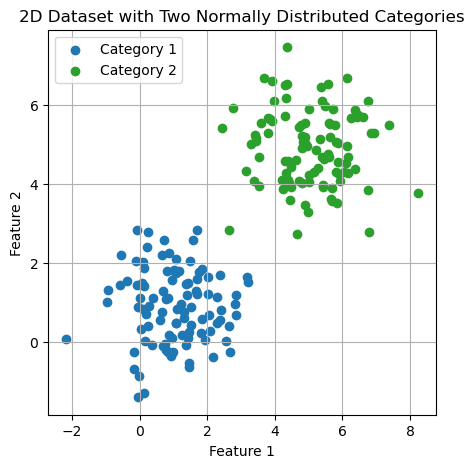

In [3]:
# Plot the 2D dataset
plt.figure(figsize=(5, 5))
plt.scatter(data_cluster1[:, 0], data_cluster1[:, 1], c='tab:blue', label='Category 1')
plt.scatter(data_cluster2[:, 0], data_cluster2[:, 1], c='tab:green', label='Category 2')
plt.title("2D Dataset with Two Normally Distributed Categories")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.grid(True)
plt.show()

In [4]:
def euclidean_distance(A, B):
    diff = A[:, np.newaxis, :] - B[np.newaxis, :, :]
    return np.sqrt(np.sum(diff**2, axis=2))

In [5]:
def initialize_centroids(X, K, seed=None):
    rng = np.random.default_rng(seed)
    selected_indices = rng.choice(X.shape[0], size=K, replace=False)
    centroids = X[selected_indices]
    return centroids

In [6]:
centroids_init = initialize_centroids(data_2d, K=2, seed=student_id)

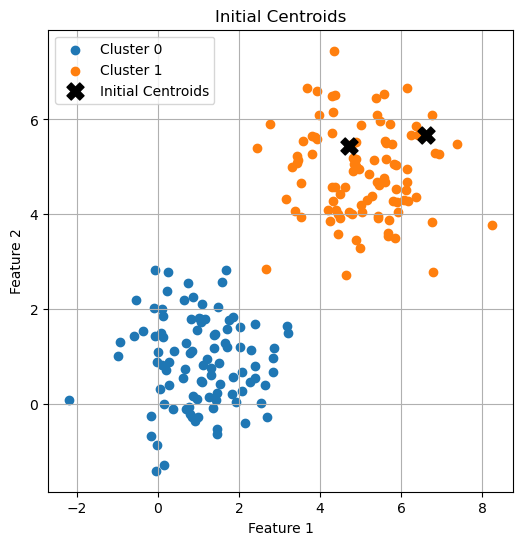

In [7]:
import matplotlib.pyplot as plt

# Plotting the clusters and initial centroids
plt.figure(figsize=(6, 6))
plt.scatter(data_cluster1[:, 0], data_cluster1[:, 1], c='C0', label='Cluster 0')
plt.scatter(data_cluster2[:, 0], data_cluster2[:, 1], c='C1', label='Cluster 1')
plt.scatter(centroids_init[:, 0], centroids_init[:, 1], 
            c='black', marker='X', s=150, label='Initial Centroids')
plt.title("Initial Centroids")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.grid(True)
plt.show()

In [8]:
def euclidean_distance(A, B):
    diff = A[:, np.newaxis, :] - B[np.newaxis, :, :]
    sq_diff = diff ** 2
    return np.sqrt(np.sum(sq_diff, axis=2))

In [9]:
from scipy.spatial.distance import cdist

def assign_clusters(X, centroids, metric='euclidean'):
    # Compute pairwise distances between points and centroids
    distance_matrix = cdist(X, centroids, metric=metric)
    
    # Assign each point to the nearest centroid
    cluster_labels = np.argmin(distance_matrix, axis=1)
    
    return cluster_labels


In [10]:
def update_centroids(X, labels, K, prev_centroids):
    updated_centroids = []

    for k in range(K):
        cluster_points = X[labels == k]

        # If cluster has members, compute mean; else retain previous centroid
        if cluster_points.size > 0:
            centroid = cluster_points.mean(axis=0)
        else:
            centroid = prev_centroids[k]

        updated_centroids.append(centroid)

    return np.vstack(updated_centroids)

In [11]:
def kmeans(X, K, max_iters=100, tol=1e-6, seed=0, verbose=True):
    rng = np.random.default_rng(seed)
    centroids = X[rng.choice(X.shape[0], size=K, replace=False)]

    for iteration in range(1, max_iters + 1):
        cluster_labels = assign_clusters(X, centroids)
        updated_centroids = update_centroids(X, cluster_labels, K, centroids)

        if np.allclose(updated_centroids, centroids, atol=tol):
            if verbose:
                print(f"Converged in {iteration} iterations.")
            break

        centroids = updated_centroids

    return centroids, cluster_labels


In [12]:
K = 2
centroids_final, labels_2d = kmeans(data_2d, K, seed=student_id, verbose=True)

Converged in 4 iterations.


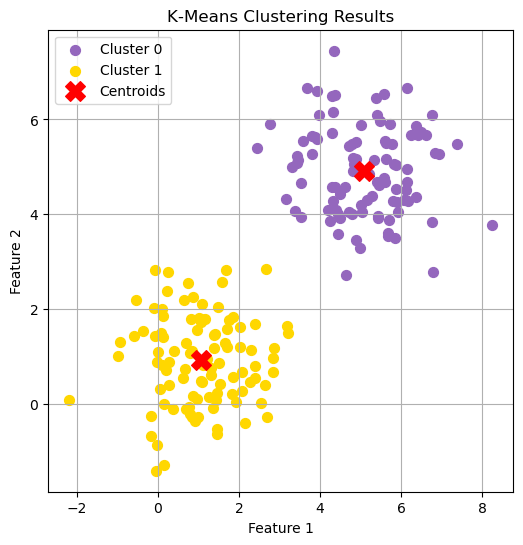

In [13]:
colors = ['tab:purple', 'gold']
plt.figure(figsize=(6, 6))

for k, color in enumerate(colors):
    cluster_points = data_2d[labels_2d == k]
    plt.scatter(cluster_points[:, 0], cluster_points[:, 1], 
                c=color, label=f'Cluster {k}', s=50)

plt.scatter(centroids_final[:, 0], centroids_final[:, 1], 
            c='red', marker='X', s=200, label='Centroids')

plt.title('K‑Means Clustering Results')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.grid(True)
plt.show()


In [14]:
def read_idx(filename):
    with gzip.open(filename, 'rb') as f:
        zero, data_type, dims = struct.unpack('>HBB', f.read(4))
        shape = tuple(struct.unpack('>I', f.read(4))[0] for _ in range(dims))
        data = np.frombuffer(f.read(), dtype=np.uint8).reshape(shape)
    return data